Here we try out different time series preprocessing strategies on actual HCP data.

Our final preprocessing config uses:

- No motion spike interpolation. Introduces artifacts, and is unnecessary since the data have already been denoised.
- Bandpass filtering with even padding. Even padding reduces boundary artifacts compared to odd padding.
- Global signal regression. Standard across prior works, and visually appears to sharpen data.

In [ ]:
import os
from fractions import Fraction
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from neuromaps.datasets import fetch_fslr
from nisc.cifti import get_cifti_surf_data
from sklearn.preprocessing import scale
from tqdm import tqdm

import yaspy
from arfcexp import timeseries as ts
from arfcexp.video import save_video

In [2]:
import pyvista as pv

pv.start_xvfb()

In [3]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [4]:
HCP_TR = 0.72

project_root = Path(os.environ["PROJECT_ROOT"])
hcp_root = Path(os.environ["HCP_1200_DIR"])

ts_preproc_dir = project_root / "results/test_hcp_timeseries_preprocessing"
ts_preproc_dir.mkdir(exist_ok=True)

In [5]:
n_subs = 4

sub_list_path = (
    project_root / "resources/subject_lists/hcp_complete_data_867_subject_list.txt"
)
subjects = np.genfromtxt(sub_list_path, dtype=str)[:n_subs]
print(subjects)

['181131' '245333' '106824' '187547']


In [6]:
pattern = "rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii"

paths = {sub: next(iter((hcp_root / sub).rglob(pattern))) for sub in subjects}
print("\n".join(map(str, paths.values())))

/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/181131/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/245333/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/106824/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii
/ocean/projects/med220004p/shared/data_derived/HCP/HCP_1200/187547/MNINonLinear/Results/rfMRI_REST1_LR/rfMRI_REST1_LR_Atlas_MSMAll_hp2000_clean.dtseries.nii


In [7]:
def load_cifti(path: Path) -> np.ndarray:
    """Load cifti time series data."""
    data = nib.load(path)
    data = get_cifti_surf_data(data)
    data = np.ascontiguousarray(data.T)
    return data

In [8]:
all_series = {sub: load_cifti(path) for sub, path in paths.items()}

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [9]:
# Get mask of vertices containing valid data
mask = np.std(all_series[subjects[0]], axis=0) > np.finfo(np.float16).eps
print(f"Mask size: {mask.sum()}/{mask.size} {mask.mean():.2f}")

Mask size: 59412/64984 0.91


In [10]:
# Get random sample vertices for testing and visualization
n_sample_vertices = 4096
n_sub_sample_vertices = 320

rng = np.random.default_rng(42)
sample_indices = np.sort(
    rng.choice(mask.nonzero()[0], n_sample_vertices, replace=False)
)
sub_sample_indices = np.sort(
    rng.choice(n_sample_vertices, n_sub_sample_vertices, replace=False)
)

print("Sample vertices:", sample_indices[:10].tolist())
print("Sub-sample vertices:", sub_sample_indices[:10].tolist())

Sample vertices: [77, 79, 108, 119, 175, 181, 182, 448, 902, 903]
Sub-sample vertices: [11, 30, 31, 49, 55, 61, 70, 99, 119, 128]


In [11]:
# Get corresponding censoring sample masks
hcp_fd_dir = project_root / "results/hcp_1200_rfmri_fd"
hcp_fd = pd.read_parquet(hcp_fd_dir / "hcp_1200_rfmri_fd.parquet")
hcp_fd = hcp_fd.set_index(["sub", "task", "dir"])

print(hcp_fd.iloc[:4, :4])

                    mod mag  n_frames   mean_fd
sub    task  dir                               
100206 REST1 LR   rfMRI  3T      1200  0.099991
             RL   rfMRI  3T      1200  0.105217
       REST2 LR   rfMRI  3T      1200  0.123617
             RL   rfMRI  3T      1200  0.106712


In [12]:
sample_masks = {
    sub: hcp_fd.loc[(sub, "REST1", "LR"), "sample_mask"] for sub in subjects
}

for sub, sample_mask in sample_masks.items():
    print(f"{sub}: n_frames={sample_mask.sum()}", sample_mask.shape)

181131: n_frames=1148 (1200,)
245333: n_frames=1188 (1200,)
106824: n_frames=1166 (1200,)
187547: n_frames=1154 (1200,)


Carpet plots for different preprocessing strategies.

In [13]:
def preprocess(series: np.ndarray, sample_mask: np.ndarray) -> dict[str, np.ndarray]:
    configs = {
        # initial base preprocessing, minus GSR
        "base": {
            "interp": "spline",
            "gsr": False,
            "padtype": "odd",
        },
        "nointerp": {
            "interp": None,
            "gsr": False,
            "padtype": "odd",
        },
        "padeven": {
            "interp": None,
            "gsr": False,
            "padtype": "even",
        },
        "gsr": {
            "interp": None,
            "gsr": True,
            "padtype": "even",
        },
    }

    results = {}

    # copy of data and baseline scaling only
    results["raw"] = series
    results["scaled"] = scale(series)

    for name, cfg in tqdm(configs.items()):
        results[name] = ts.preprocess_timeseries(
            series, tr=HCP_TR, sample_mask=sample_mask, **cfg
        )

    return results

In [14]:
results = {}

for sub in subjects:
    series = all_series[sub][:, sample_indices]
    sample_mask = sample_masks[sub]
    results[sub] = preprocess(series, sample_mask)


  0%|                                                                    | 0/4 [00:00<?, ?it/s]


 25%|███████████████                                             | 1/4 [00:03<00:10,  3.37s/it]


 50%|██████████████████████████████                              | 2/4 [00:06<00:06,  3.04s/it]


 75%|█████████████████████████████████████████████               | 3/4 [00:08<00:02,  2.91s/it]


100%|████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.88s/it]

...


 25%|███████████████                                             | 1/4 [00:03<00:10,  3.37s/it]


 50%|██████████████████████████████                              | 2/4 [00:06<00:06,  3.03s/it]


 75%|█████████████████████████████████████████████               | 3/4 [00:08<00:02,  2.91s/it]


100%|████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.87s/it]


100%|████████████████████████████████████████████████████████████| 4/4 [00:11<00:00,  2.94s/it]

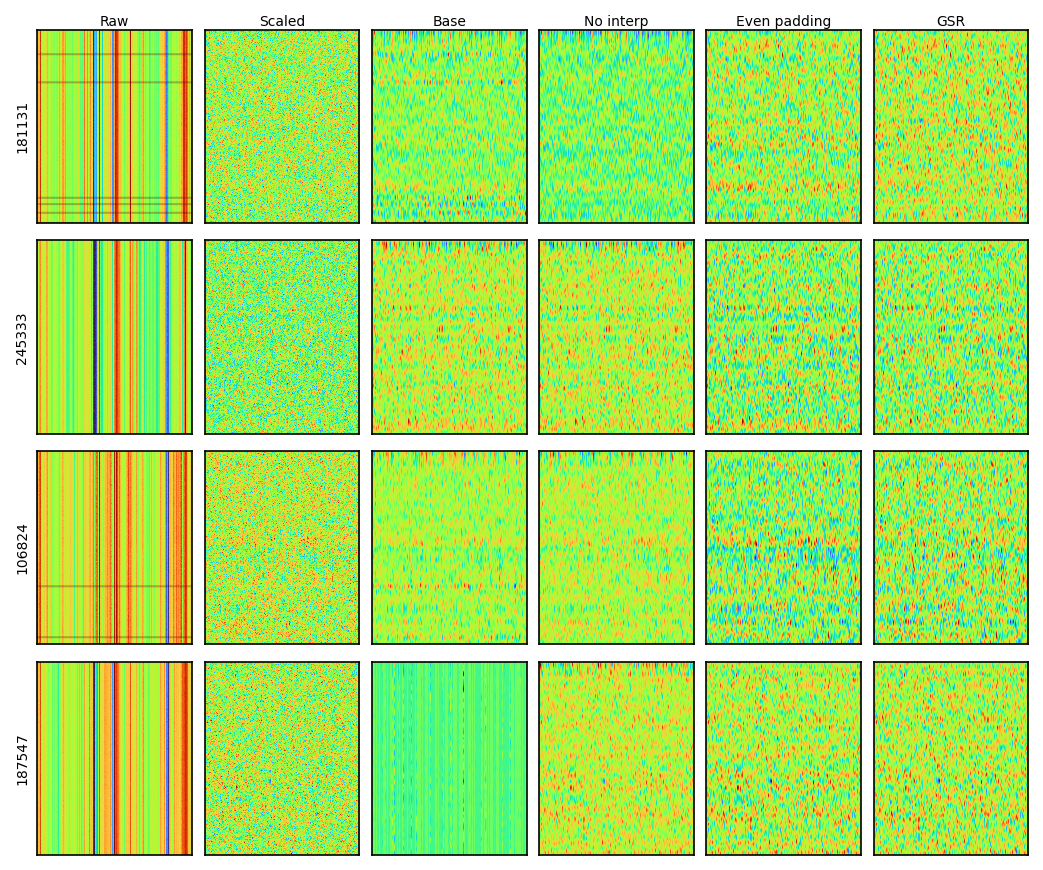

In [15]:
n_samples = 400
n_features = n_sub_sample_vertices
offset = 0

titles = {
    "raw": "Raw",
    "scaled": "Scaled",
    "base": "Base",
    "nointerp": "No interp",
    "padeven": "Even padding",
    "gsr": "GSR",
}

nr = len(subjects)
nc = len(titles)
plotw = 2 * PLOTW / nc
ploth = (n_samples / n_features) * plotw

f, axs = plt.subplots(nr, nc, figsize=(plotw * nc, ploth * nr), layout="constrained")

for ii, sub in enumerate(subjects):
    for jj, (key, title) in enumerate(titles.items()):
        data = results[sub][key]

        plt.sca(axs[ii, jj])

        # vmin, vmax = np.nanquantile(data, [0.001, 0.999])

        plt.imshow(
            data[offset : offset + n_samples, sub_sample_indices],
            interpolation="nearest",
            cmap="turbo",
            # vmin=vmin,
            # vmax=vmax,
        )

        if jj == 0:
            censor_mask = np.where(sample_masks[sub], np.nan, 1.0)
            censor_mask = np.tile(censor_mask[:, None], (1, n_features))
            plt.imshow(
                censor_mask[offset : offset + n_samples, :n_features],
                cmap="Reds",
                vmin=0.0,
                alpha=0.3,
            )
        plt.xticks([])
        plt.yticks([])
        if ii == 0:
            plt.title(title, fontsize="small", pad=2)
        if jj == 0:
            plt.ylabel(sub, fontsize="small")

plt.savefig(ts_preproc_dir / f"hcp_timeseries_preprocessing.{FORMAT}")

Generate videos of fully preprocessed data

In [16]:
preproc_series = {
    sub: ts.preprocess_timeseries(series, tr=HCP_TR)
    for sub, series in tqdm(all_series.items())
}


  0%|                                                                    | 0/4 [00:00<?, ?it/s]


 25%|███████████████                                             | 1/4 [00:27<01:21, 27.21s/it]


 50%|██████████████████████████████                              | 2/4 [00:54<00:54, 27.26s/it]


 75%|█████████████████████████████████████████████               | 3/4 [01:21<00:27, 27.32s/it]


100%|████████████████████████████████████████████████████████████| 4/4 [01:49<00:00, 27.30s/it]


100%|████████████████████████████████████████████████████████████| 4/4 [01:49<00:00, 27.29s/it]

In [17]:
surfaces = fetch_fslr()
surf_lh_path, surf_rh_path = surfaces["inflated"]
sulc_lh_path, sulc_rh_path = surfaces["sulc"]
print(surf_lh_path)
print(sulc_lh_path)

/jet/home/clane2/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_inflated.surf.gii
/jet/home/clane2/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_desc-sulc_midthickness.shape.gii


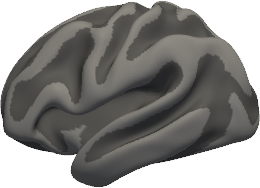

In [18]:
plotter_lh = yaspy.Plotter(surf_lh_path, hemi="lh", sulc=sulc_lh_path)
plotter_rh = yaspy.Plotter(surf_rh_path, hemi="rh", sulc=sulc_rh_path)

plotter_lh.screenshot()

In [19]:
def generate_overlay_frames(
    series: np.ndarray,
    n_frames: int = 160,
    stride: int = 3,
    vmin: float = 0.0,
    vmax: float = 20000.0,
):
    for ii in tqdm(range(n_frames)):
        plotter_lh.clear()
        plotter_rh.clear()

        frame = series[stride * ii]
        frame_lh, frame_rh = np.split(frame, 2)

        plotter_lh.overlay(frame_lh, cmap="turbo", vmin=vmin, vmax=vmax)
        plotter_rh.overlay(frame_rh, cmap="turbo", vmin=vmin, vmax=vmax)

        img = yaspy.montage(
            [
                [
                    plotter_lh.screenshot("lateral", color="black"),
                    plotter_rh.screenshot("lateral", color="black"),
                ],
                [
                    plotter_lh.screenshot("medial", color="black"),
                    plotter_rh.screenshot("medial", color="black"),
                ],
            ],
            pad=8,
            shareh=True,
        )
        yield img

In [20]:
stride = 3
n_frames = 100
fps = Fraction(int(100 * 4 / (HCP_TR * stride)), 100)
vmin = -2.5
vmax = 2.5

for sub in subjects:
    save_video(
        ts_preproc_dir / f"hcp_1200_rfmri_{sub}_preproc.mp4",
        generate_overlay_frames(
            preproc_series[sub],
            n_frames=n_frames,
            stride=stride,
            vmin=vmin,
            vmax=vmax,
        ),
        fps=fps,
    )


  0%|                                                                  | 0/100 [00:00<?, ?it/s]


  1%|▌                                                         | 1/100 [00:00<00:20,  4.89it/s]


  2%|█▏                                                        | 2/100 [00:00<00:16,  6.03it/s]


  3%|█▋                                                        | 3/100 [00:00<00:14,  6.49it/s]


  4%|██▎                                                       | 4/100 [00:00<00:14,  6.74it/s]

...


 97%|███████████████████████████████████████████████████████▎ | 97/100 [00:14<00:00,  7.17it/s]


 98%|███████████████████████████████████████████████████████▊ | 98/100 [00:14<00:00,  7.25it/s]


 99%|████████████████████████████████████████████████████████▍| 99/100 [00:14<00:00,  7.35it/s]


100%|████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  7.32it/s]


100%|████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.90it/s]